# Get One Step Plot


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

os.getcwd()
os.listdir("runs/2026-03-26_19-52-30_512x512_omp12")
# Set specific sizes for axis labels and tick labels
plt.rcParams['axes.labelsize'] = 14   # Fontsize of the x and y axis labels
plt.rcParams['xtick.labelsize'] = 14  # Fontsize of the x tick labels
plt.rcParams['ytick.labelsize'] = 14  # Fontsize of the y tick labels

In [3]:
def load_step(file):
    import pandas as pd
    import numpy as np

    df = pd.read_csv(file, comment="#")

    x_vals = np.sort(df["x"].unique())
    y_vals = np.sort(df["y"].unique())

    nx = len(x_vals)
    ny = len(y_vals)

    fields = {}
    for col in ["rho","u","v","p","E","rhou","rhov","H"]:
        fields[col] = df[col].to_numpy().reshape(ny, nx)

    return x_vals, y_vals, fields

In [4]:

nx = 512
scheme = "FirstOrder"

if nx == 256:
    DATA_DIR = Path(f"runs/2026-03-04_17-20-21_256x256_omp12/{scheme}_256x256_omp12/data")
else:
    DATA_DIR = Path(f"runs/2026-03-26_21-37-44_512x512_omp12/{scheme}_512x512_omp12/data")

print("DATA_DIR =", DATA_DIR.resolve())
print("Exists   =", DATA_DIR.exists())

files = sorted(
    glob.glob(str(DATA_DIR / "step_*.csv")),
    key=lambda f: int(Path(f).stem.split("_")[1])
)

print("Found", len(files), "files")
print("First 5:", [os.path.basename(f) for f in files[:5]])
print("Last 5: ", [os.path.basename(f) for f in files[-5:]])

DATA_DIR = /home/lucas/Documents/Masters/Codes/laser_solver/runs/2026-03-26_21-37-44_512x512_omp12/FirstOrder_512x512_omp12/data
Exists   = True
Found 13 files
First 5: ['step_0000.csv', 'step_0100.csv', 'step_0200.csv', 'step_0300.csv', 'step_0400.csv']
Last 5:  ['step_0800.csv', 'step_0900.csv', 'step_1000.csv', 'step_1100.csv', 'step_1124.csv']


Using: runs/2026-03-26_21-37-44_512x512_omp12/FirstOrder_512x512_omp12/data/step_0000.csv


Grid size = 512 x 512
time = 0.0


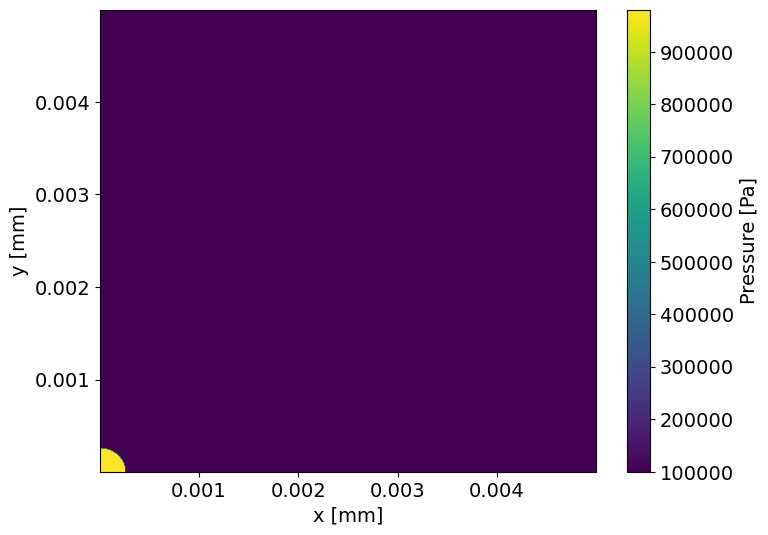

In [5]:
step_index = 0  # change this to any frame you want

file_to_plot = files[step_index]
print("Using:", file_to_plot)

df = pd.read_csv(file_to_plot, comment="#")

x_vals = np.sort(df["x"].unique())
y_vals = np.sort(df["y"].unique())

nx = len(x_vals)
ny = len(y_vals)

print(f"Grid size = {nx} x {ny}")

rho = df["rho"].to_numpy().reshape(ny, nx)
p   = df["p"].to_numpy().reshape(ny, nx)
u   = df["u"].to_numpy().reshape(ny, nx)
v   = df["v"].to_numpy().reshape(ny, nx)
E   = df["E"].to_numpy().reshape(ny, nx)
rhou   = df["rhou"].to_numpy().reshape(ny, nx)
rhov   = df["rhov"].to_numpy().reshape(ny, nx)
H   = df["H"].to_numpy().reshape(ny, nx)

with open(file_to_plot) as f:
    first_line = f.readline()

time = float(first_line.split("=")[1])
print("time =", time)

x, y, fields = load_step(file_to_plot)

plt.figure(figsize=(8,6))

plt.imshow(
    fields["p"],
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    aspect="auto"
)

plt.colorbar(label="Pressure [Pa]")
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
#plt.savefig(f"Figures/{scheme}_shock_loc_2ms.png", dpi = 300)
plt.show()

In [62]:

#scheme = "TENO5"

DATA_DIR = Path(f"runs/2026-03-26_19-52-30_512x512_omp12/{scheme}_512x512_omp12/data")


print("DATA_DIR =", DATA_DIR.resolve())
print("Exists   =", DATA_DIR.exists())

files = sorted(
    glob.glob(str(DATA_DIR / "step_*.csv")),
    key=lambda f: int(Path(f).stem.split("_")[1])
)

print("Found", len(files), "files")
print("First 5:", [os.path.basename(f) for f in files[:5]])
print("Last 5: ", [os.path.basename(f) for f in files[-5:]])


DATA_DIR = /home/lucas/Documents/Masters/Codes/laser_solver/runs/2026-03-26_19-52-30_512x512_omp12/FirstOrder_512x512_omp12/data
Exists   = True
Found 21 files
First 5: ['step_0000.csv', 'step_0100.csv', 'step_0200.csv', 'step_0300.csv', 'step_0400.csv']
Last 5:  ['step_1600.csv', 'step_1700.csv', 'step_1800.csv', 'step_1900.csv', 'step_1931.csv']


In [63]:
step_index = -1 # change this to any frame you want

file_to_plot = files[step_index]
print("Using:", file_to_plot)

with open(file_to_plot) as f:
    first_line = f.readline()

time = float(first_line.split("=")[1])
print("time =", time)

Using: runs/2026-03-26_19-52-30_512x512_omp12/FirstOrder_512x512_omp12/data/step_1931.csv
time = 2e-06


Using: runs/2026-03-26_19-52-30_512x512_omp12/FirstOrder_512x512_omp12/data/step_1931.csv
Grid size = 512 x 512
time = 2e-06


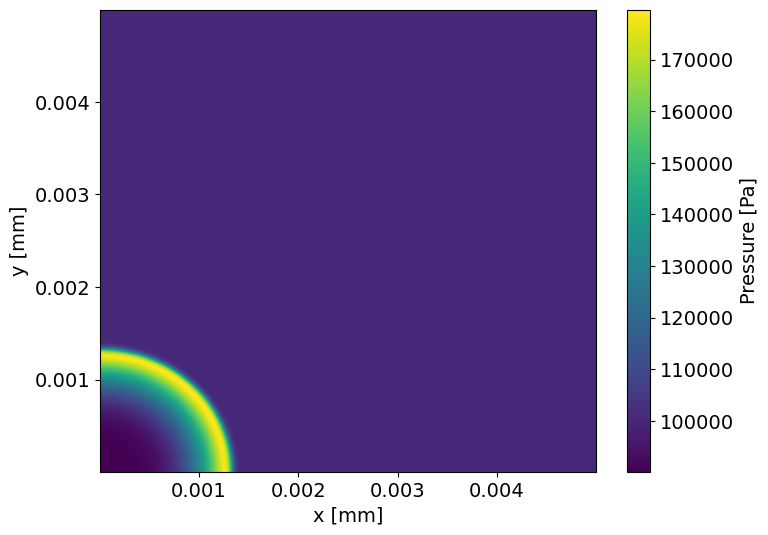

In [64]:
step_index = -1  # change this to any frame you want

file_to_plot = files[step_index]
print("Using:", file_to_plot)

df = pd.read_csv(file_to_plot, comment="#")

x_vals = np.sort(df["x"].unique())
y_vals = np.sort(df["y"].unique())

nx = len(x_vals)
ny = len(y_vals)

print(f"Grid size = {nx} x {ny}")

rho = df["rho"].to_numpy().reshape(ny, nx)
p   = df["p"].to_numpy().reshape(ny, nx)
u   = df["u"].to_numpy().reshape(ny, nx)
v   = df["v"].to_numpy().reshape(ny, nx)
E   = df["E"].to_numpy().reshape(ny, nx)
rhou   = df["rhou"].to_numpy().reshape(ny, nx)
rhov   = df["rhov"].to_numpy().reshape(ny, nx)
H   = df["H"].to_numpy().reshape(ny, nx)

with open(file_to_plot) as f:
    first_line = f.readline()

time = float(first_line.split("=")[1])
print("time =", time)

x, y, fields = load_step(file_to_plot)

plt.figure(figsize=(8,6))

plt.imshow(
    fields["p"],
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    aspect="auto"
)


#plt.xticks(np.arange(0,0.005,.00025))
plt.colorbar(label="Pressure [Pa]")
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
#plt.title(f"Pressure Field | {scheme} | {time:.2e} s")
plt.savefig(f"Figures/{scheme}_shock_loc_2ms.png", dpi = 300)

plt.show()




In [65]:
R = 208.13
T = 2.5e4 
p= 9.8e5

rho = p/(R*T)

print(rho)

0.1883438235718061


Using run root: /home/lucas/Documents/Masters/Codes/laser_solver/runs/2026-03-12_15-18-24_512x512_omp12

Scheme: FirstOrder
DATA_DIR = /home/lucas/Documents/Masters/Codes/laser_solver/runs/2026-03-12_15-18-24_512x512_omp12/FirstOrder_512x512_omp12/data
Exists   = True
Found 32 files
First 3: ['step_0000.csv', 'step_0100.csv', 'step_0200.csv']
Last 3:  ['step_2900.csv', 'step_3000.csv', 'step_3040.csv']
Using: runs/2026-03-12_15-18-24_512x512_omp12/FirstOrder_512x512_omp12/data/step_3040.csv


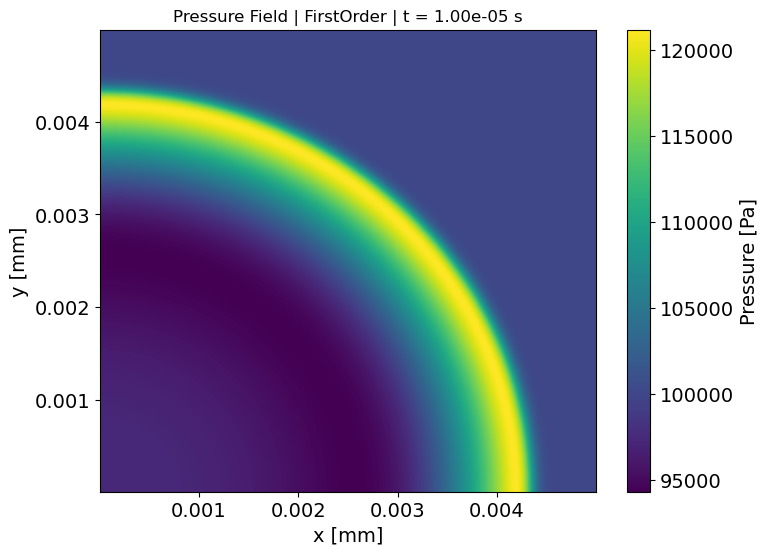

Saved: Figures/FirstOrder_presentation_location_later #shock_loc_1ms.png

Scheme: WENO3
DATA_DIR = /home/lucas/Documents/Masters/Codes/laser_solver/runs/2026-03-12_15-18-24_512x512_omp12/WENO3_512x512_omp12/data
Exists   = True
Found 53 files
First 3: ['step_0000.csv', 'step_0100.csv', 'step_0200.csv']
Last 3:  ['step_5000.csv', 'step_5100.csv', 'step_5143.csv']
Using: runs/2026-03-12_15-18-24_512x512_omp12/WENO3_512x512_omp12/data/step_5143.csv


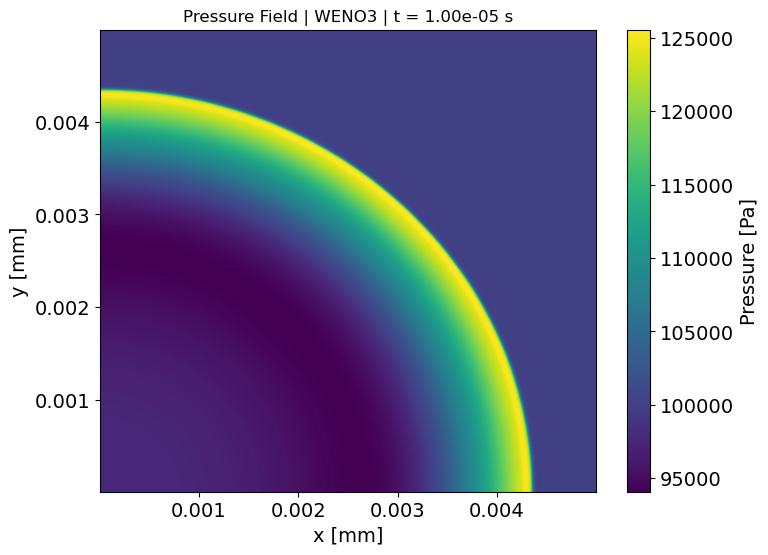

Saved: Figures/WENO3_presentation_location_later #shock_loc_1ms.png

Scheme: WENO5
DATA_DIR = /home/lucas/Documents/Masters/Codes/laser_solver/runs/2026-03-12_15-18-24_512x512_omp12/WENO5_512x512_omp12/data
Exists   = True
Found 50 files
First 3: ['step_0000.csv', 'step_0100.csv', 'step_0200.csv']
Last 3:  ['step_4700.csv', 'step_4800.csv', 'step_4877.csv']
Using: runs/2026-03-12_15-18-24_512x512_omp12/WENO5_512x512_omp12/data/step_4877.csv


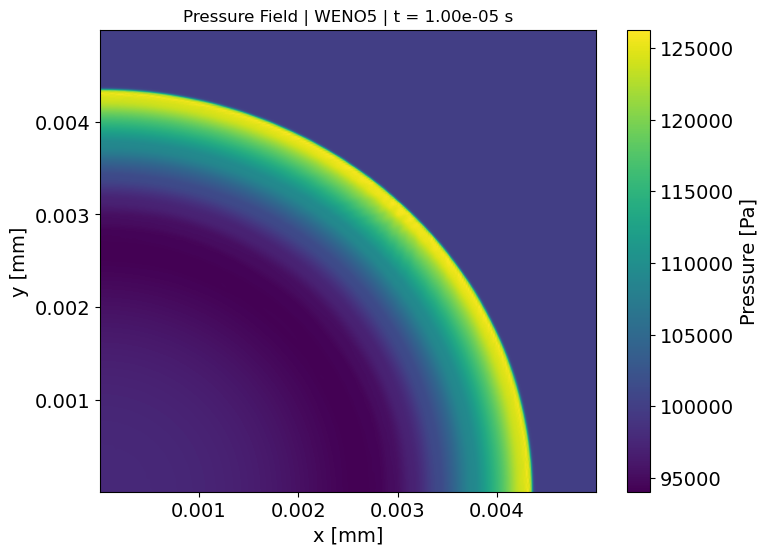

Saved: Figures/WENO5_presentation_location_later #shock_loc_1ms.png

Scheme: TENO5
DATA_DIR = /home/lucas/Documents/Masters/Codes/laser_solver/runs/2026-03-12_15-18-24_512x512_omp12/TENO5_512x512_omp12/data
Exists   = True
Found 52 files
First 3: ['step_0000.csv', 'step_0100.csv', 'step_0200.csv']
Last 3:  ['step_4900.csv', 'step_5000.csv', 'step_5076.csv']
Using: runs/2026-03-12_15-18-24_512x512_omp12/TENO5_512x512_omp12/data/step_5076.csv


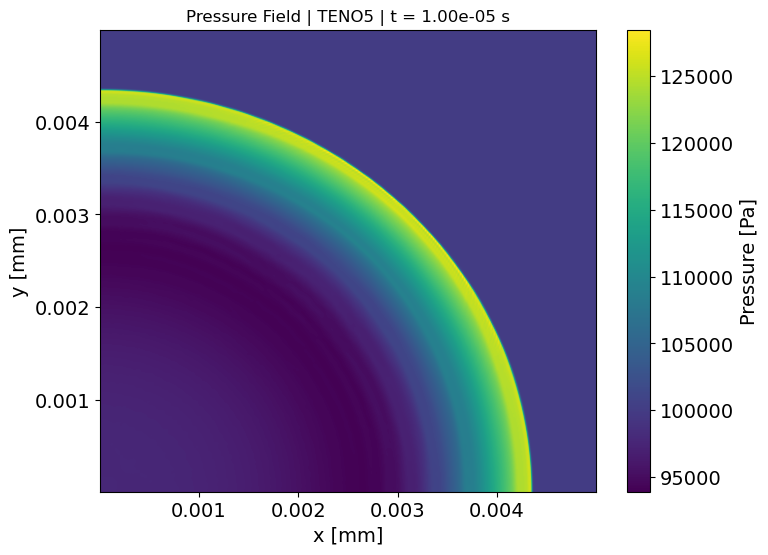

Saved: Figures/TENO5_presentation_location_later #shock_loc_1ms.png


In [70]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
schemes = ["FirstOrder", "WENO3", "WENO5", "TENO5"]
grid_nx = 512
step_index = -1          # last timestep
field_name = "p"         # field to plot
omp_threads = 12
tim = 1 #ms

# output folder
fig_dir = Path("Figures")
fig_dir.mkdir(exist_ok=True)

# Set specific sizes for axis labels and tick labels
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# --------------------------------------------------
# HELPER FUNCTION
# --------------------------------------------------
def load_step(file):
    df = pd.read_csv(file, comment="#")

    x_vals = np.sort(df["x"].unique())
    y_vals = np.sort(df["y"].unique())

    nx = len(x_vals)
    ny = len(y_vals)

    fields = {}
    for col in ["rho", "u", "v", "p", "E", "rhou", "rhov", "H"]:
        fields[col] = df[col].to_numpy().reshape(ny, nx)

    with open(file, "r") as f:
        first_line = f.readline()

    time = float(first_line.split("=")[1])

    return x_vals, y_vals, fields, time

# --------------------------------------------------
# CHOOSE RUN FOLDER
# --------------------------------------------------
if grid_nx == 256:
    run_root = Path(f"runs/2026-03-04_17-20-21_{grid_nx}x{grid_nx}_omp{omp_threads}")
else:
    run_root = Path(f"runs/2026-03-12_15-18-24_{grid_nx}x{grid_nx}_omp{omp_threads}")

print("Using run root:", run_root.resolve())

# --------------------------------------------------
# LOOP THROUGH ALL SCHEMES
# --------------------------------------------------
for scheme in schemes:
    data_dir = run_root / f"{scheme}_{grid_nx}x{grid_nx}_omp{omp_threads}" / "data"

    print(f"\nScheme: {scheme}")
    print("DATA_DIR =", data_dir.resolve())
    print("Exists   =", data_dir.exists())

    files = sorted(
        glob.glob(str(data_dir / "step_*.csv")),
        key=lambda f: int(Path(f).stem.split("_")[1])
    )

    if len(files) == 0:
        print("No files found for", scheme)
        continue

    print("Found", len(files), "files")
    print("First 3:", [os.path.basename(f) for f in files[:3]])
    print("Last 3: ", [os.path.basename(f) for f in files[-3:]])

    file_to_plot = files[step_index]
    print("Using:", file_to_plot)

    x, y, fields, time = load_step(file_to_plot)

    plt.figure(figsize=(8, 6))

    im = plt.imshow(
        fields[field_name],
        origin="lower",
        extent=[x.min(), x.max(), y.min(), y.max()],
        aspect="auto"
    )

    plt.colorbar(im, label="Pressure [Pa]")
    plt.xlabel("x [mm]")   # change to [m] if your coordinates are in meters
    plt.ylabel("y [mm]")   # change to [m] if your coordinates are in meters
    plt.title(f"Pressure Field | {scheme} | t = {time:.2e} s")

    save_path = fig_dir / f"{scheme}_presentation_location_later #shock_loc_{tim}ms.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)